## In- and out-of-phase form stress (amplitude) at each layer

In [1]:
%matplotlib inline

import datetime, time
import numpy as np
import xesmf as xe
import xarray as xr
import netCDF4 as nc
import cmocean as cm
import matplotlib.ticker
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pathlib import Path
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm

import warnings
warnings.filterwarnings('ignore')

### construct in- and out-of-phase form stress

In [2]:
data_path = Path("/g/data/nm03/lxy581/evaluate/amp_phase")
data_stress = data_path / "form_stress_amp_pha_test_013.nc"
data_vel_u = data_path / "form_u_amp_pha_test_013.nc"
data_vel_v = data_path / "form_v_amp_pha_test_013.nc"

stress = xr.open_dataset(data_stress)
vel_u  = xr.open_dataset(data_vel_u)
vel_v  = xr.open_dataset(data_vel_v)

In [3]:
out_path = Path("/scratch/nm03/lxy581/mom6/archive/tides_008_global_sigma_SAL_2layer_x02/output014")
out_grid = out_path / "ocean_static.nc"

static = xr.open_dataset(out_grid)

In [4]:
stress_amp_x = stress.amp_x
stress_pha_x = stress.phase_x
u_pha = vel_u.phase_x

In [5]:
stress_amp_y = stress.amp_y
stress_pha_y = stress.phase_y
v_pha = vel_v.phase_y

#### x-dir, in

In [6]:
x_in = stress_amp_x * np.cos(stress_pha_x - u_pha)

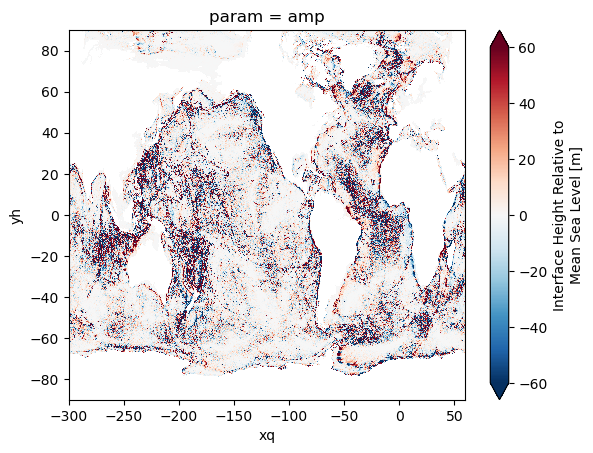

In [7]:
x_in.plot(vmin=-6e+1,vmax=6e+1,cmap="RdBu_r")

#### x-dir, out

In [8]:
x_out = stress_amp_x * np.sin(stress_pha_x - u_pha)

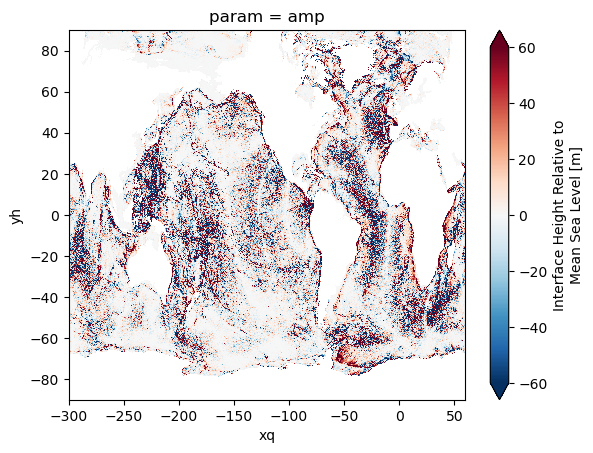

In [9]:
x_out.plot(vmin=-6e+1,vmax=6e+1,cmap="RdBu_r")

#### y-dir, in

In [10]:
y_in = stress_amp_y * np.cos(stress_pha_y - v_pha)

#### y-dir, out

In [11]:
y_out = stress_amp_y * np.sin(stress_pha_y - v_pha)

### Interpolate to a depth, identify on which side of topography these red & blue dots lie 

In [12]:
dep_path = Path("/g/data/nm03/lxy581/evaluate/amp_phase")
dep_file = dep_path / "depth_h2u_8km.nc"

dep_interp = xr.open_dataset(dep_file)
depth_u = dep_interp.depthu
depth_v = dep_interp.depthv

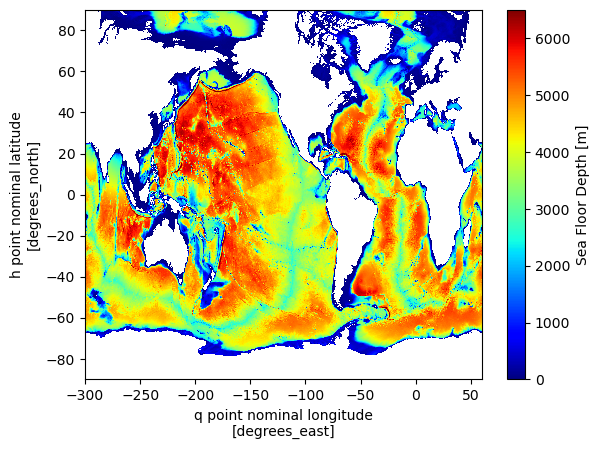

In [13]:
depth_u.plot(vmin=0,vmax=6500,cmap="jet")

In [14]:
mask_depth_u = (depth_u > 3000) & (depth_u < 3500)
# mask_depth_u.plot(vmin=0,vmax=2,cmap="RdBu_r")

In [15]:
mask_depth_v = (depth_v > 3000) & (depth_v < 3500)
# mask_depth_v.plot(vmin=0,vmax=2,cmap="RdBu_r")

In [16]:
# choose values in this depth range
x_in_cut = x_in * mask_depth_u
x_out_cut = x_out * mask_depth_u
y_in_cut = y_in * mask_depth_v
y_out_cut = y_out * mask_depth_v

#### Know which side of topography these points are at
If left side: -1
If right side: 1

In [17]:
x_in_cut.yh.isel(yh=600)

<xarray.DataArray 'yh' ()> Size: 8B
array(-61.40762581)
Coordinates:
    yh       float64 8B -61.41
    param    <U3 12B ...

In [18]:
x_in_cut_slice = x_in_cut.isel(yh=600).values
x_in_cut_slice

array([ 0., -0., -0., ..., -0.,  0.,  0.], shape=(4321,))

In [19]:
sides_u = 0 * depth_u

# diff_u = depth_u.diff(dim="xq")
diff_u = depth_u.roll(xq=-1, roll_coords=False) - depth_u

# left of topog: -1, right of topog: 1
sides_u = xr.where(diff_u > 0, 1.0, -1.0)

In [20]:
print(diff_u.shape)
print(sides_u.shape)

(3270, 4321)
(3270, 4321)


### Blue: left of topog  | Red: right of topog

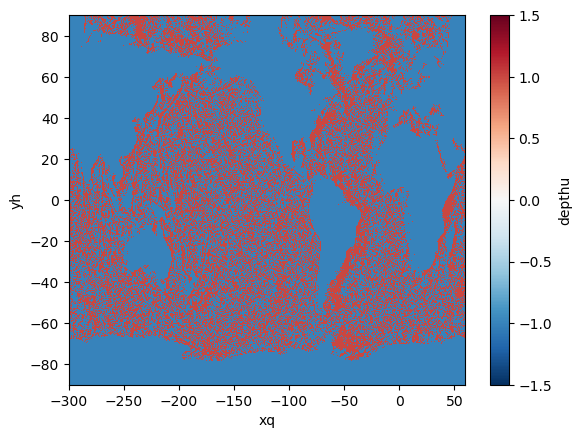

In [21]:
sides_u.plot(vmin=-1.5,vmax=1.5,cmap="RdBu_r")

In [22]:
sides_u_masked = sides_u * mask_depth_u
# sides_u_masked.plot(vmin=-1.5,vmax=1.5,cmap="RdBu_r")

In [23]:
x_in_cut_slice = x_in_cut.isel(yh=600).values
x_in_cut_slice

array([ 0., -0., -0., ..., -0.,  0.,  0.], shape=(4321,))

In [24]:
sides_u_slice = sides_u_masked.isel(yh=600).values
mask_left = (sides_u_slice == -1) & (x_in_cut_slice != 0)
ind_left = np.where(mask_left)[0]
ind_left

array([ 215,  216,  217,  218,  221,  222,  223,  224,  225,  226,  228,
        231, 1083, 1093, 1094, 1098, 1099, 1132, 1133, 1140, 1212, 1227,
       1228, 1249, 1276, 1277, 1289, 1292, 1293, 1552, 1575, 1580, 1581,
       1585, 1590, 1591, 1595, 1596, 1597, 1606, 1607, 1608, 1609, 1610,
       1618, 1619, 1620, 1623, 1624, 1632, 1633, 1634, 1640, 1641, 1642,
       1643, 1653, 1655, 1656, 1657, 1663, 1664, 1665, 1666, 1684, 1685,
       1689, 1690, 1692, 1693, 1694, 1695, 1696, 1699, 1700, 1701, 1705,
       1706, 1707, 1717, 1718, 1719, 1720, 1722, 1727, 1728, 1731, 1732,
       1782, 1788, 1789, 1795, 1796, 1798, 1799, 1804, 1806, 1807, 1808,
       1811, 1812, 1813, 1816, 1817, 1818, 1823, 1824, 1825, 1830, 1831,
       1834, 1835, 2818, 2821, 2823, 2824, 2826, 2827, 2845, 2883, 2887,
       2888, 2991, 2992, 2996, 2997, 2998, 3002, 3006, 3007, 3008, 3013,
       3014, 3015, 3016, 3017, 3118, 3119, 3120, 3121, 3122, 3127, 3128,
       3129, 3133, 3134, 3144, 3179, 3180, 3189, 31

In [25]:
x_in_cut_slice[ind_left[:]]

array([ 1.08191581e+01,  5.61295998e+00,  7.60545662e+00,  7.97977826e+00,
       -1.79939538e+00,  4.22960012e+00,  5.99897642e+00,  7.63907139e+00,
        5.75039997e+00,  3.61667201e+00, -8.25814470e-01,  5.65795511e+00,
       -9.04293423e+01, -1.71749175e+02, -7.53365586e+01,  3.81047801e+00,
       -1.03029388e+02,  1.16249026e+01, -7.05215458e+01,  3.91848390e+00,
        6.11631828e-01, -3.13541711e+00,  5.63838626e+01,  1.68051920e+01,
        6.96540754e+01,  1.39714421e+02,  6.83166919e+01,  2.17319943e+00,
        3.82667852e+01, -6.52202548e+00,  6.96097386e+01,  5.31352302e-01,
        4.23065704e+00, -1.51696381e+00,  8.16229800e+00,  1.85377558e+01,
        2.20009186e+00,  1.12137884e+01,  1.11971402e+01, -1.46193629e+00,
        2.95088039e+00,  5.35030758e+00,  1.62508458e+01,  4.04877891e+01,
        1.09984435e+01,  9.88505763e+00,  7.20460599e+00,  1.12162758e+01,
        1.37561477e+01,  2.38081086e+01,  1.55331945e+01,  9.82357142e+00,
        8.75159800e-01,  

In [26]:
mask_right = (sides_u_slice == 1) & (x_in_cut_slice != 0)
ind_right = np.where(mask_right)[0]
ind_right

array([ 219,  220,  227,  229,  230,  313,  314,  315, 1084, 1085, 1086,
       1095, 1096, 1097, 1225, 1226, 1248, 1265, 1266, 1284, 1285, 1286,
       1290, 1291, 1294, 1295, 1550, 1551, 1553, 1554, 1571, 1579, 1582,
       1583, 1584, 1586, 1587, 1588, 1589, 1592, 1593, 1594, 1598, 1599,
       1600, 1601, 1602, 1603, 1604, 1605, 1615, 1616, 1617, 1621, 1622,
       1625, 1626, 1627, 1635, 1636, 1637, 1638, 1639, 1644, 1645, 1652,
       1654, 1658, 1659, 1660, 1661, 1662, 1667, 1668, 1669, 1670, 1671,
       1686, 1687, 1688, 1691, 1697, 1698, 1702, 1703, 1704, 1716, 1723,
       1724, 1725, 1726, 1730, 1783, 1784, 1785, 1786, 1787, 1790, 1791,
       1792, 1793, 1794, 1797, 1800, 1801, 1802, 1805, 1809, 1810, 1814,
       1815, 1819, 1820, 1821, 1822, 1826, 1827, 1828, 1829, 1832, 1833,
       1836, 1837, 1841, 2810, 2811, 2819, 2820, 2822, 2825, 2828, 2829,
       2830, 2831, 2846, 2847, 2851, 2852, 2884, 2885, 2995, 2999, 3000,
       3001, 3003, 3004, 3005, 3009, 3010, 3011, 30

In [27]:
x_in_cut_slice[ind_right[:]]

array([-1.55130004e+00, -1.30967782e+00,  6.72935190e-01,  2.56161819e+00,
       -7.65166828e+00,  8.57729083e+00,  1.35093929e+01,  1.56774910e+01,
       -1.95568547e+01,  3.68599869e+01,  7.61547332e+01, -3.47977692e+01,
        5.70250110e+01,  5.71043145e+01, -4.32406944e+01, -1.80961123e+01,
       -2.60222137e+01, -2.48443276e+01, -3.24661686e+01, -4.27466801e+01,
        2.77506798e+00, -4.26742343e+01, -1.07024357e+01, -2.92136999e+00,
       -1.29159647e+01, -4.09984064e+01,  9.13344109e+00, -1.22782041e+01,
        1.84522540e+01, -2.28723292e+01,  8.01489536e-01, -1.36513826e+01,
       -1.93888025e-02, -8.21674412e+00, -9.82857767e+00,  3.37648153e+00,
       -7.19835806e+00, -2.15291704e+01, -1.56991548e+01,  5.19962811e+00,
       -9.36656583e+00, -8.60260568e+00,  3.09653798e+00, -4.20433789e+00,
       -6.02645239e+00, -5.21474440e+00, -4.52636416e+00, -4.52662281e+00,
       -5.44683395e+00, -5.34790047e+00, -8.00555779e+00, -1.82492892e+01,
       -3.03297561e+01,  

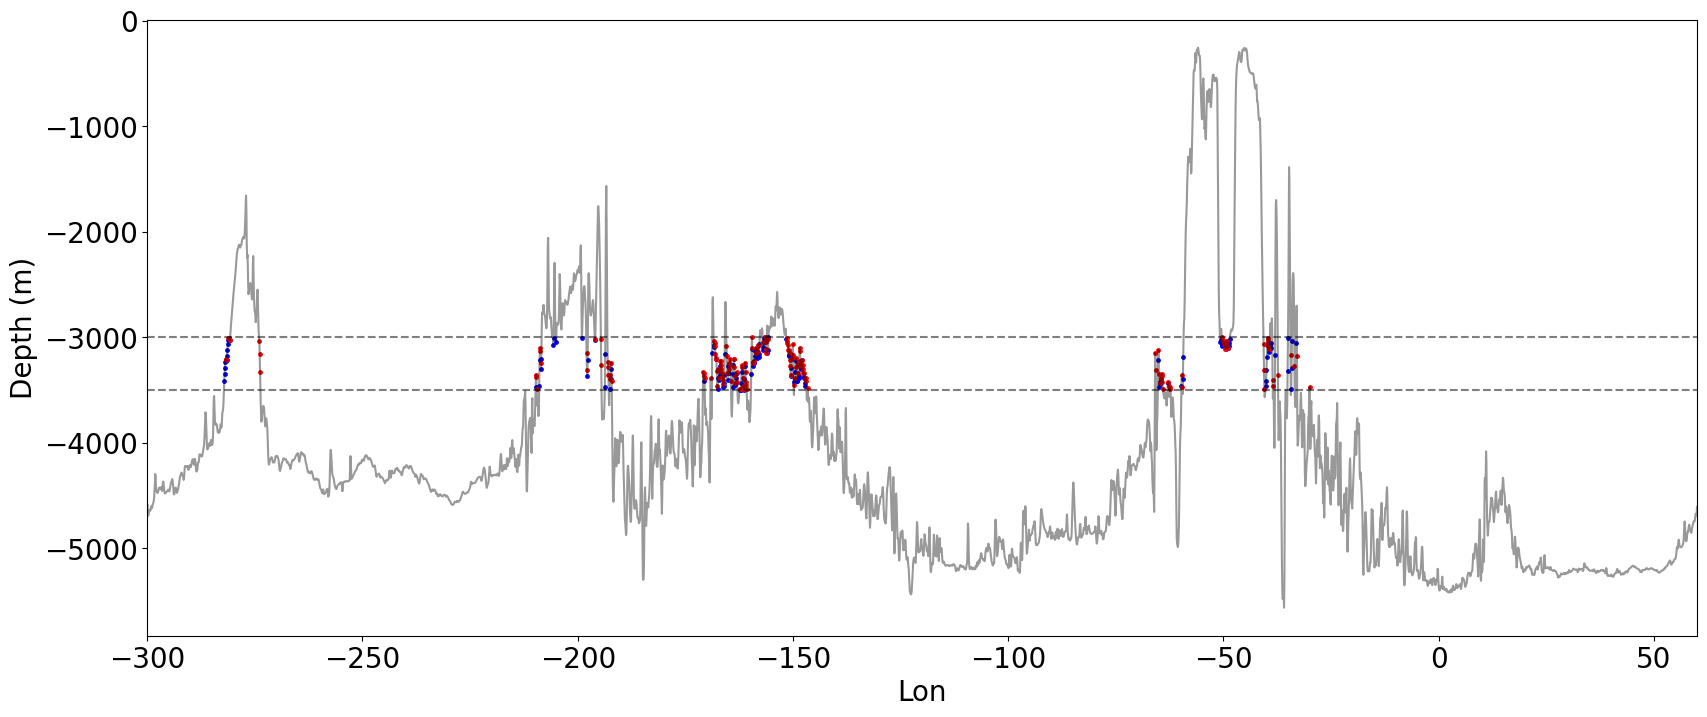

In [28]:
fig = plt.figure(figsize=(20, 8))
xq = depth_u.xq.values
dep_slice = -depth_u.isel(yh=600).values
plt.plot(xq,dep_slice,'k',alpha=0.4)
plt.xlim(np.nanmin(xq),np.nanmax(xq))
plt.tick_params(labelsize=20)
plt.ylabel('Depth (m)',fontsize=20)
plt.xlabel('Lon',fontsize=20)
plt.plot((xq[0],xq[-1]),(-3000,-3000),'k--',alpha=0.5)
plt.plot((xq[0],xq[-1]),(-3500,-3500),'k--',alpha=0.5)
plt.scatter(xq[ind_left],dep_slice[ind_left],marker='o',s=6, c='blue')
plt.scatter(xq[ind_right],dep_slice[ind_right],marker='o',s=6, c='red')
plt.savefig('/g/data/nm03/lxy581/evaluate/amp_phase/select_points_across_topog.png', dpi=600, bbox_inches='tight')

In [29]:
mask_form_pos = x_in_cut_slice > 0
mask_form_neg = x_in_cut_slice < 0

ind_pos = np.where(mask_form_pos)[0]
ind_neg = np.where(mask_form_neg)[0]

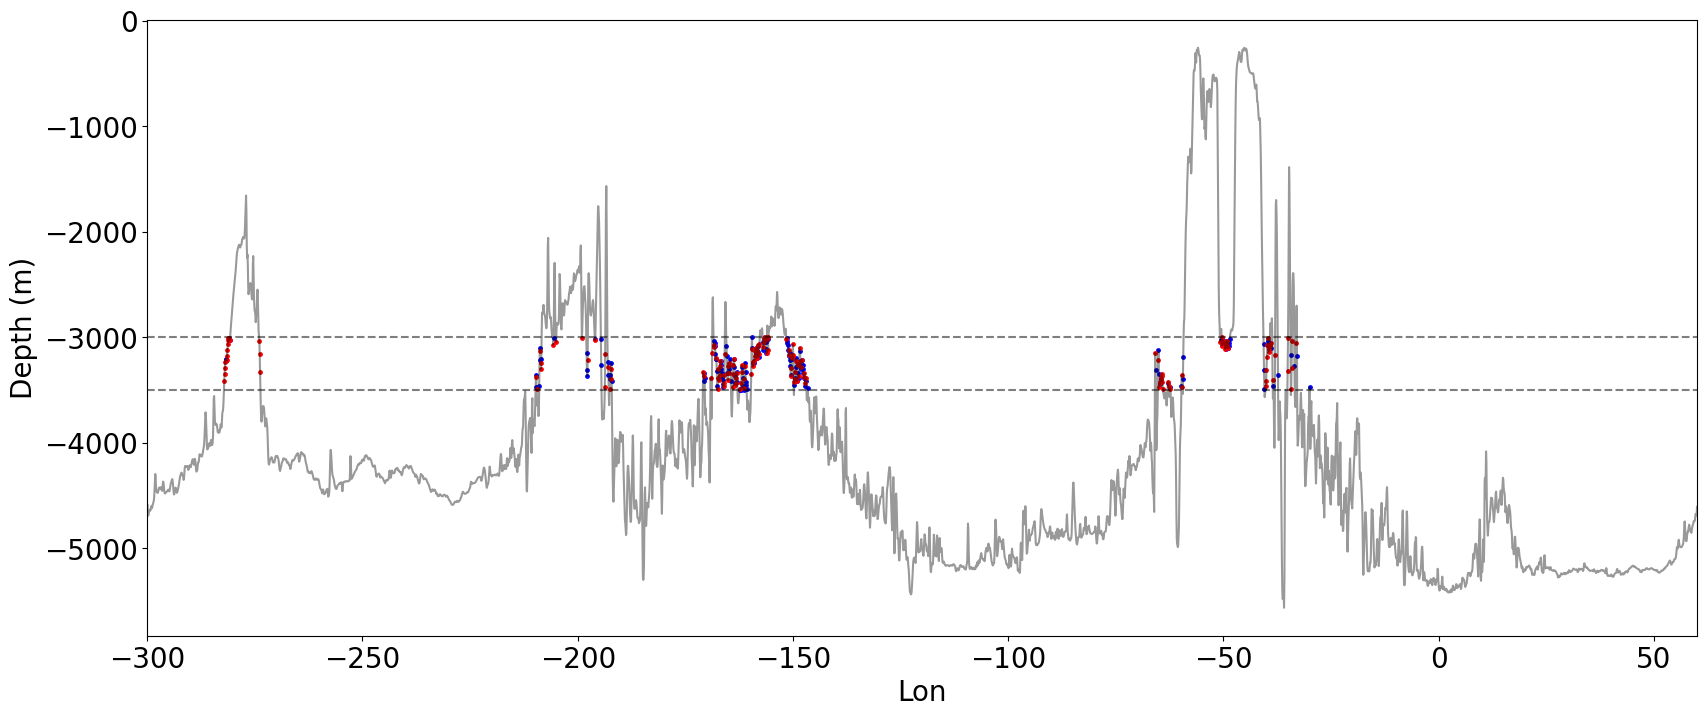

In [30]:
fig = plt.figure(figsize=(20, 8))
xq = depth_u.xq.values
dep_slice = -depth_u.isel(yh=600).values
plt.plot(xq,dep_slice,'k',alpha=0.4)
plt.xlim(np.nanmin(xq),np.nanmax(xq))
plt.tick_params(labelsize=20)
plt.ylabel('Depth (m)',fontsize=20)
plt.xlabel('Lon',fontsize=20)
plt.plot((xq[0],xq[-1]),(-3000,-3000),'k--',alpha=0.5)
plt.plot((xq[0],xq[-1]),(-3500,-3500),'k--',alpha=0.5)
plt.scatter(xq[ind_neg],dep_slice[ind_neg],marker='o',s=6, c='blue')
plt.scatter(xq[ind_pos],dep_slice[ind_pos],marker='o',s=6, c='red')
plt.savefig('/g/data/nm03/lxy581/evaluate/amp_phase/select_points_across_topog_form_stress.png', dpi=600, bbox_inches='tight')